# L6: Building Specialized Review Agents

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Note <code>(Kernel Starting)</code>:</b> This notebook takes about 30 seconds to be ready to use. You may start and watch the video while you wait.</p>

![Specialized Review Agents](L6.png)

In [1]:
# Warning control
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import sys
import pandas as pd
import plotly.io as pio
from dotenv import load_dotenv

sys.path.insert(0, os.path.abspath('..'))
pio.renderers.default = 'png'
load_dotenv()

if not os.getenv('OPENAI_API_KEY'):
    print('⚠️  WARNING: OPENAI_API_KEY not set.')
else:
    print('✓ OpenAI API key loaded successfully')

✓ OpenAI API key loaded successfully


<div style="background-color:#fff6ff; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">
<p> 💻 &nbsp; <b>Access <code>requirements.txt</code> file:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Open"</em>.</p>

<p> ⬇ &nbsp; <b>Download Notebooks:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Download as"</em> and select <em>"Notebook (.ipynb)"</em>.</p>

<p> 📒 &nbsp; For more help, please see the <em>"Appendix – Tips, Help, and Download"</em> Lesson.</p>
</div>

## Section 1: Setup Context Engine

In [3]:
from src.context_engine import chunk_repository, embed_chunks, ContextRetriever
from src.data.toy_repository import get_toy_repository

print("Building context engine...")
repo = get_toy_repository()
chunks = chunk_repository(repo)
embedded_chunks = embed_chunks(chunks)

retriever = ContextRetriever()
retriever.create_index(embedded_chunks)

print(f"\n✓ Context engine ready with {len(embedded_chunks)} chunks indexed")

Building context engine...

✓ Context engine ready with 99 chunks indexed


## Section 2: The Ensemble Architecture

### 1. Security Agent
**Focus**: Security vulnerabilities requiring domain expertise
- SQL injection, XSS, auth bypass
- Hardcoded secrets, weak crypto
- Uses OWASP knowledge and attack patterns

### 2. Pattern Compliance Agent
**Focus**: Violations of established codebase patterns
- Missing authentication decorators
- Inconsistent error handling
- Missing locks, rate limits
- Deviation from project conventions

### 3. Ensemble Strategy
- Run both specialists in parallel
- Combine findings they both agree on (high confidence)
- Add unique high/medium-severity findings from either specialist
- Deduplicate aggressively

```
PR + Context → [Security Agent] ──┐
               [Pattern Agent]  ──┼→ Combine → Deduplicate → Final Review
```

In [4]:
from src.review_agents.specialized import SECURITY_AGENT_PROMPT, PATTERN_AGENT_PROMPT
from src.review_agents.reviewer import DEFAULT_REVIEW_PROMPT

print("Agent Prompts:")
print(f"  General Agent:  {len(DEFAULT_REVIEW_PROMPT):,} characters")
print(f"  Security Agent: {len(SECURITY_AGENT_PROMPT):,} characters (detailed OWASP guidance)")
print(f"  Pattern Agent:  {len(PATTERN_AGENT_PROMPT):,} characters (pattern enforcement rules)")
print("\nSpecialized agents have 4x longer prompts with domain-specific expertise")

Agent Prompts:
  General Agent:  411 characters
  Security Agent: 2,305 characters (detailed OWASP guidance)
  Pattern Agent:  1,724 characters (pattern enforcement rules)

Specialized agents have 4x longer prompts with domain-specific expertise


## Section 3: Full Evaluation Across All PRs

In [5]:
from src.data.sample_prs import load_all_prs
from src.helpers.evaluation_helpers import evaluate_general_and_ensemble

all_prs = load_all_prs()
print(f"Loaded {len(all_prs)} PRs for evaluation\n")
print("Evaluating General vs Ensemble across all PRs (this takes a few minutes)...\n")

results_general, results_ensemble = evaluate_general_and_ensemble(all_prs, retriever)

print("\n" + "="*80)
print("EVALUATION COMPLETE")
print("="*80)

Loaded 15 PRs for evaluation

Evaluating General vs Ensemble across all PRs (this takes a few minutes)...

  Processing PR 1/15: pr_001_auth_bypass
  Processing PR 2/15: pr_002_sql_injection
  Processing PR 3/15: pr_003_hardcoded_secret
  Processing PR 4/15: pr_004_missing_error_handling
  Processing PR 5/15: pr_005_race_condition
  Processing PR 6/15: pr_006_xss_vulnerability
  Processing PR 7/15: pr_007_weak_crypto
  Processing PR 8/15: pr_008_missing_rate_limit
  Processing PR 9/15: pr_009_insecure_deserialization
  Processing PR 10/15: pr_010_missing_input_validation
  Processing PR 11/15: pr_011_info_disclosure
  Processing PR 12/15: pr_012_path_traversal
  Processing PR 13/15: pr_013_cors_misconfiguration
  Processing PR 14/15: pr_014_timing_attack
  Processing PR 15/15: pr_015_unvalidated_redirect

EVALUATION COMPLETE


<p style="background-color:#f7fff8; padding:15px; border-width:3px; border-color:#e0f0e0; border-style:solid; border-radius:6px"> 🚨
&nbsp; <b>Different Run Results:</b> The output generated by AI chat models can vary with each execution due to their dynamic, probabilistic nature. Don't be surprised if your results differ from those shown in the video.</p>

## Section 4: Metrics Comparison

In [6]:
from src.helpers.evaluation_helpers import calculate_metrics

# Calculate metrics
metrics_general = calculate_metrics(results_general)
metrics_ensemble = calculate_metrics(results_ensemble)

# Create comparison table
metrics_df = pd.DataFrame([
    {'Approach': 'General (Lab 2)', 'Precision': f"{metrics_general['precision']:.2%}",
     'Recall': f"{metrics_general['recall']:.2%}", 'F1 Score': f"{metrics_general['f1']:.2%}"},
    {'Approach': 'Ensemble (Specialized)', 'Precision': f"{metrics_ensemble['precision']:.2%}",
     'Recall': f"{metrics_ensemble['recall']:.2%}", 'F1 Score': f"{metrics_ensemble['f1']:.2%}"}
])

display(metrics_df)

# Calculate improvements
f1_improvement = metrics_ensemble['f1'] - metrics_general['f1']
precision_improvement = metrics_ensemble['precision'] - metrics_general['precision']
recall_improvement = metrics_ensemble['recall'] - metrics_general['recall']

print(f"\n🎯 Ensemble Improvements over General Agent:")
print(f"  Precision: {precision_improvement:+.1%}")
print(f"  Recall:    {recall_improvement:+.1%}")
print(f"  F1 Score:  {f1_improvement:+.1%}")

if f1_improvement > 0.05:
    print("\n✓ Specialized agents working together OUTPERFORM general agent!")
else:
    print("\n≈ Performance is similar")

,Approach,Precision,Recall,F1 Score
0,General (Lab 2),44.12%,100.00%,61.22%
1,Ensemble (Specialized),60.00%,90.00%,72.00%



🎯 Ensemble Improvements over General Agent:
  Precision: +15.9%
  Recall:    -10.0%
  F1 Score:  +10.8%

✓ Specialized agents working together OUTPERFORM general agent!


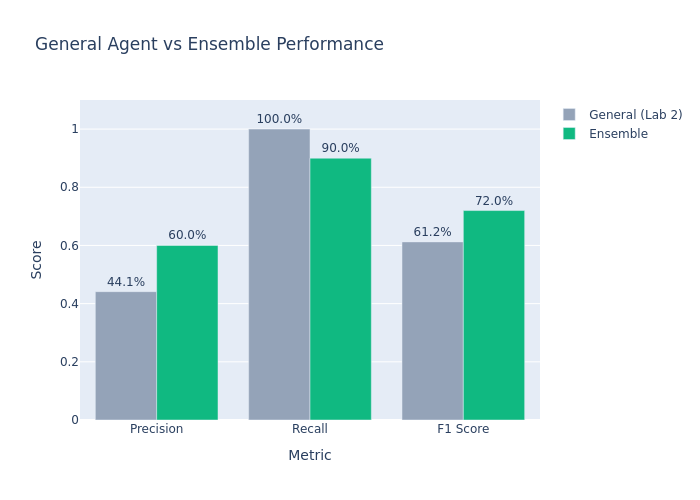


Key Insight:
  Ensemble achieves 72.0% F1 vs 61.2% for general agent
  Improvement comes from combining security + pattern expertise


In [7]:
from src.helpers.plotting_helpers import plot_general_vs_ensemble

metrics_names = ['Precision', 'Recall', 'F1 Score']
general_values = [metrics_general['precision'], metrics_general['recall'], metrics_general['f1']]
ensemble_values = [metrics_ensemble['precision'], metrics_ensemble['recall'], metrics_ensemble['f1']]

plot_general_vs_ensemble(metrics_names, general_values, ensemble_values)

print("\nKey Insight:")
print(f"  Ensemble achieves {metrics_ensemble['f1']:.1%} F1 vs {metrics_general['f1']:.1%} for general agent")
print(f"  Improvement comes from combining security + pattern expertise")

## Section 8: Per-PR Performance

In [8]:
from src.helpers.evaluation_helpers import build_per_pr_table, print_per_pr_summary

per_pr_df, per_pr_summary = build_per_pr_table(all_prs, results_general, results_ensemble)

print("Per-PR Performance (Issues Found / Expected):\n")
display(per_pr_df)

print_per_pr_summary(per_pr_summary)

Per-PR Performance (Issues Found / Expected):



,PR ID,Expected,General,Ensemble,Winner
0,pr_001_auth_bypass,2,"2/2 found, 5 total","2/2 found, 4 total",Ensemble
1,pr_002_sql_injection,2,"2/2 found, 4 total","1/2 found, 2 total",General
2,pr_003_hardcoded_secret,2,"2/2 found, 5 total","1/2 found, 2 total",General
3,pr_004_missing_error_handling,2,"2/2 found, 7 total","2/2 found, 5 total",Ensemble
4,pr_005_race_condition,2,"2/2 found, 4 total","2/2 found, 3 total",Ensemble
5,pr_006_xss_vulnerability,2,"2/2 found, 4 total","2/2 found, 3 total",Ensemble
6,pr_007_weak_crypto,2,"2/2 found, 5 total","2/2 found, 3 total",Ensemble
7,pr_008_missing_rate_limit,2,"2/2 found, 5 total","2/2 found, 4 total",Ensemble
8,pr_009_insecure_deserialization,2,"2/2 found, 4 total","2/2 found, 2 total",Ensemble
9,pr_010_missing_input_validation,2,"2/2 found, 5 total","2/2 found, 3 total",Ensemble



Summary:
  Ensemble wins:  11/15 PRs
  General wins:   3/15 PRs
  Ties:           1/15 PRs
  Ensemble perfect catches: 12/15 PRs (100% recall)
